            Sentiment Analysis System

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")

print("Path to dataset files:", path)

100%|██████████| 2.55M/2.55M [00:00<00:00, 46.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4


In [ ]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, 'Tweets.csv'))

df.shape


(14640, 15)

In [ ]:
print(df.columns.tolist())

['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


In [ ]:
df[['text', 'airline_sentiment']].head(10)

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative
5,@VirginAmerica seriously would pay $30 a fligh...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",positive
7,@VirginAmerica Really missed a prime opportuni...,neutral
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive
9,"@VirginAmerica it was amazing, and arrived an ...",positive


In [ ]:
print(df['airline_sentiment'].value_counts())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [ ]:
# Keep equal samples from each class
df_balanced = df.groupby('airline_sentiment').sample(n=2363, random_state=42)

# Keep only the 2 columns we need
df_balanced = df_balanced[['text', 'airline_sentiment']].reset_index(drop=True)

# Verify it worked
print(df_balanced['airline_sentiment'].value_counts())
print("Total rows:", len(df_balanced))

airline_sentiment
negative    2363
neutral     2363
positive    2363
Name: count, dtype: int64
Total rows: 7089


In [ ]:
print("NEGATIVE TWEET")
for tweet in df_balanced[df_balanced['airline_sentiment'] == 'negative']['text'].head(3).values:
    print("-", tweet)
    print()

print(" NEUTRAL TWEETS ")
for tweet in df_balanced[df_balanced['airline_sentiment'] == 'neutral']['text'].head(3).values:
    print("-", tweet)
    print()

print("POSITIVE TWEETS")
for tweet in df_balanced[df_balanced['airline_sentiment'] == 'positive']['text'].head(3).values:
    print("-", tweet)
    print()

=== NEGATIVE TWEETS ===
- @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi

- @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.

- @united installed and working are not the same. Kicked me out after an hour and wouldn't let me back in. Four wasted hours.

=== NEUTRAL TWEETS ===
- JetBlue reading the NYTimes. “@JetBlue: Our fleet's on fleek. http://t.co/lvIrTDtqly”

- @USAirways just realized my @AmericanAir advantage number wasn't used for my flight.  How do I get my ff miles?

- @united I submitted a status match last week and have not heard back. Im a delta customer looking to switch to United. Please assist.

=== POSITIVE TWEETS ===
- @JetBlue you don't remember our date Monday night back to NYC? #heartbroken

- @USAirways thank you finally got our bag. Customer services reps were wonderful.

- @VirginAmerica anothe

In [ ]:
import re

def clean_tweet(text):
    text = text.lower()                            # lowercase everything
    text = re.sub(r'@\w+', '', text)               # remove @mentions
    text = re.sub(r'http\S+', '', text)            # remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)          # remove # but keep word
    text = re.sub(r'[^a-z\s]', '', text)           # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra spaces
    return text

# Apply to the whole dataset
df_balanced['clean_text'] = df_balanced['text'].apply(clean_tweet)

# Compare before and after
print("BEFORE:", df_balanced['text'].iloc[0])
print()
print("AFTER: ", df_balanced['clean_text'].iloc[0])

BEFORE: @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi

AFTER:  gate c iad u released passengers to board wothers deplaning peopleon bridge while next flight board


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words and len(w) > 1]
    return ' '.join(filtered)

df_balanced['clean_text'] = df_balanced['clean_text'].apply(remove_stopwords)

# See the result
print("AFTER stopword removal:")
print(df_balanced['clean_text'].iloc[0])

AFTER stopword removal:
gate iad released passengers board wothers deplaning peopleon bridge next flight board


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(lemmatized)

df_balanced['clean_text'] = df_balanced['clean_text'].apply(lemmatize_text)

# Compare a few examples
for i in range(3):
    print("Original :", df_balanced['text'].iloc[i])
    print("Cleaned  :", df_balanced['clean_text'].iloc[i])
    print()


[nltk_data] Downloading package wordnet to /root/nltk_data...


Original : @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi
Cleaned  : gate iad released passenger board wothers deplaning peopleon bridge next flight board

Original : @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.
Cleaned  : connecting charlotte houston mechanical issue determined qd take checked bag

Original : @united installed and working are not the same. Kicked me out after an hour and wouldn't let me back in. Four wasted hours.
Cleaned  : installed working kicked hour wouldnt let back four wasted hour



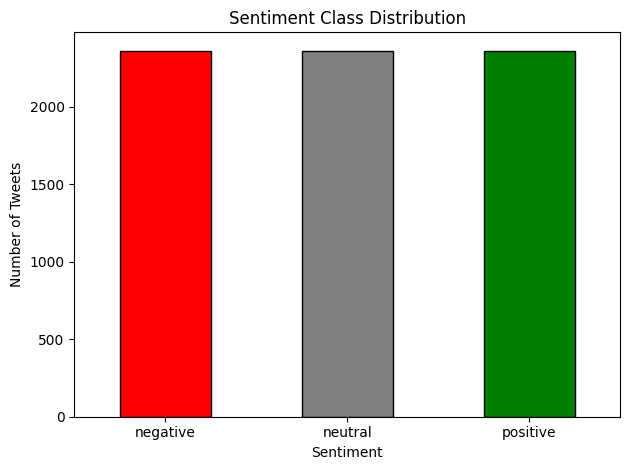

In [ ]:
import matplotlib.pyplot as plt

# Plot class distribution
df_balanced['airline_sentiment'].value_counts().plot(
    kind='bar',
    color=['red', 'gray', 'green'],
    edgecolor='black'
)

plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Check for empty tweets after cleaning
empty = df_balanced[df_balanced['clean_text'].str.strip() == '']
print("Empty tweets after cleaning:", len(empty))

# Remove them if any exist
df_balanced = df_balanced[df_balanced['clean_text'].str.strip() != ''].reset_index(drop=True)
print("Final dataset size:", len(df_balanced))

Empty tweets after cleaning: 13
Final dataset size: 7076


In [ ]:
from sklearn.model_selection import train_test_split

X = df_balanced['clean_text']
y = df_balanced['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps class balance in both splits
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print()
print("Train class distribution:")
print(y_train.value_counts())

Training samples: 5660
Testing samples : 1416

Train class distribution:
airline_sentiment
positive    1888
negative    1888
neutral     1884
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape :", X_test_tfidf.shape)

Training matrix shape: (5660, 5000)
Testing matrix shape : (1416, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Test the model
y_pred = lr_model.predict(X_test_tfidf)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7344632768361582

              precision    recall  f1-score   support

    negative       0.72      0.75      0.74       473
     neutral       0.68      0.69      0.68       471
    positive       0.81      0.76      0.79       472

    accuracy                           0.73      1416
   macro avg       0.74      0.73      0.73      1416
weighted avg       0.74      0.73      0.73      1416



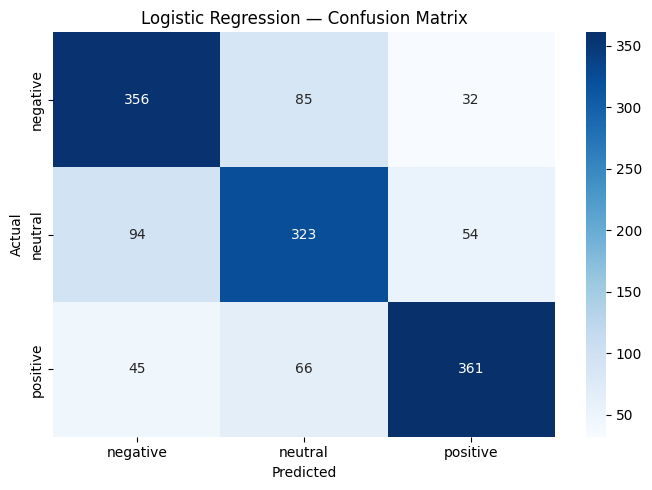

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['negative','neutral','positive'])

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])

plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
!pip install gensim
from gensim.models import Word2Vec

# Word2Vec needs a list of word lists
sentences = [text.split() for text in X_train]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size = 100,   # each word becomes 100 numbers
    window      = 5,     # looks at 5 words around each word
    min_count   = 2,     # ignore words appearing less than twice
    workers     = 4,
    epochs      = 10
)

print("Vocabulary size:", len(w2v_model.wv))
print()
print("Most similar words to 'delayed':")
print(w2v_model.wv.most_similar('delayed', topn=5))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.3 MB/s eta 0:00:00
Vocabulary size: 2985

Most similar words to 'delayed':
[('delay', 0.9988549947738647), ('dfw', 0.9985016584396362), ('rebooked', 0.9984725713729858), ('due', 0.9982503652572632), ('late', 0.9981001615524292)]


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad to same length
X_train_pad = pad_sequences(X_train_seq, maxlen=50, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=50, padding='post', truncating='post')

print("Shape of training data:", X_train_pad.shape)
print("Example encoded tweet:")
print(X_train_pad[0])

Shape of training data: (5660, 50)
Example encoded tweet:
[ 57 105  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [ ]:
# Build embedding matrix
vocab_size = 5000
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, index in tokenizer.word_index.items():
    if index < vocab_size:
        if word in w2v_model.wv:
            embedding_matrix[index] = w2v_model.wv[word]

# Check how many words got a vector
covered = np.count_nonzero(embedding_matrix.sum(axis=1))
print(f"Words covered by Word2Vec: {covered} out of {vocab_size}")
print(f"Coverage: {covered/vocab_size*100:.1f}%")

Words covered by Word2Vec: 2985 out of 5000
Coverage: 59.7%


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

model = Sequential([
    # Layer 1: Embedding - converts word numbers to Word2Vec vectors
    Embedding(
        input_dim    = vocab_size,
        output_dim   = embedding_dim,
        weights      = [embedding_matrix],
        input_length = 50,
        trainable    = True
    ),

    # Layer 2: Bidirectional LSTM - reads tweet forwards AND backwards
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2)),

    # Layer 3: Second LSTM - learns higher level patterns
    Bidirectional(LSTM(32, dropout=0.2)),

    # Layer 4: Dropout - prevents overfitting
    Dropout(0.3),

    # Layer 5: Dense - final classification
    Dense(32, activation='relu'),

    # Layer 6: Output - 3 classes
    Dense(3, activation='softmax')
])

model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 500,000 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor   = 'val_accuracy',
    patience  = 3,
    restore_best_weights = True
)

history = model.fit(
    X_train_pad, y_train_enc,
    epochs          = 15,
    batch_size      = 32,
    validation_split = 0.1,
    callbacks       = [early_stop],
    verbose         = 1
)

Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accuracy: 0.3890 - loss: 1.0699 - val_accuracy: 0.6343 - val_loss: 0.8438
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.6553 - loss: 0.7992 - val_accuracy: 0.7032 - val_loss: 0.6916
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.7867 - loss: 0.5676 - val_accuracy: 0.7208 - val_loss: 0.6406
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.8518 - loss: 0.4100 - val_accuracy: 0.7102 - val_loss: 0.7189
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.8956 - loss: 0.3067 - val_accuracy: 0.6961 - val_loss: 0.8954
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.9291 - loss: 0.2217 - val_accuracy: 0.6908 - val_loss: 0.8825


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_prob = model.predict(X_test_pad)
y_pred_lstm = y_pred_prob.argmax(axis=1)

# Convert numbers back to labels
y_pred_labels = le.inverse_transform(y_pred_lstm)
y_test_labels = le.inverse_transform(y_test_enc)

print("LSTM Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print()
print(classification_report(y_test_labels, y_pred_labels))

45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step
LSTM Accuracy: 0.7337570621468926

              precision    recall  f1-score   support

    negative       0.73      0.75      0.74       473
     neutral       0.68      0.64      0.66       471
    positive       0.79      0.81      0.80       472

    accuracy                           0.73      1416
   macro avg       0.73      0.73      0.73      1416
weighted avg       0.73      0.73      0.73      1416



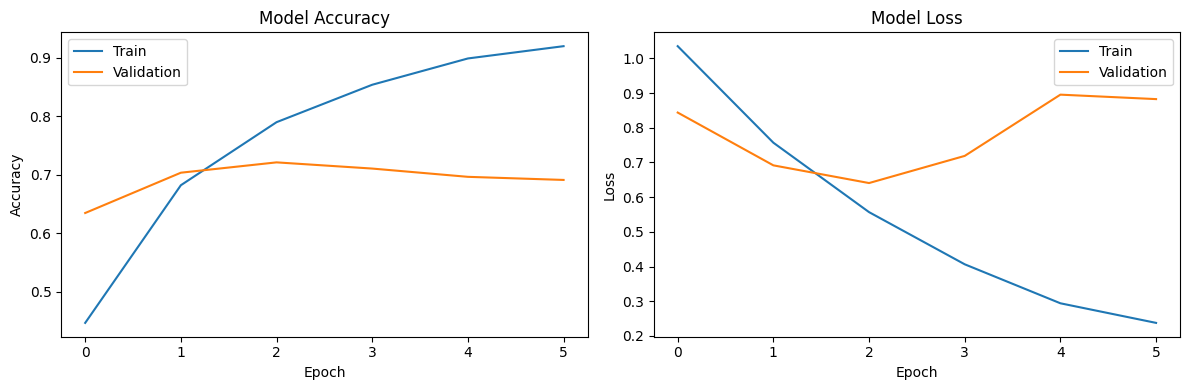

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

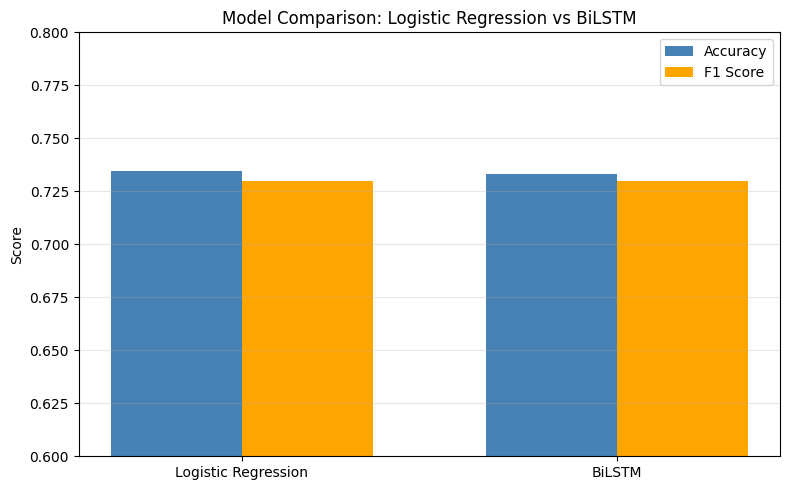

In [ ]:
models     = ['Logistic Regression', 'BiLSTM']
accuracies = [0.7344, 0.7330]
f1_scores  = [0.73,   0.73]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, f1_scores,  width, label='F1 Score',  color='orange')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs BiLSTM')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Find wrong predictions
results_df = pd.DataFrame({
    'tweet'     : X_test.values,
    'actual'    : y_test_labels,
    'predicted' : y_pred_labels
})

errors = results_df[results_df['actual'] != results_df['predicted']]

print(f"Total errors: {len(errors)} out of {len(results_df)}")
print()
print("Error breakdown:")
print(errors.groupby(['actual','predicted']).size())
print()

# Show 3 real mistake examples
print("=== EXAMPLES OF MISTAKES ===")
for _, row in errors.head(3).iterrows():
    print(f"Tweet    : {row['tweet'][:80]}")
    print(f"Actual   : {row['actual']}")
    print(f"Predicted: {row['predicted']}")
    print()

Total errors: 377 out of 1416

Error breakdown:
actual    predicted
negative  neutral      86
          positive     31
neutral   negative     97
          positive     71
positive  negative     33
          neutral      59
dtype: int64

=== EXAMPLES OF MISTAKES ===
Tweet    : thx hope iah dfw okc turned long trip today work tomorrow
Actual   : positive
Predicted: neutral

Tweet    : let say idontwannalivewithoutyourlove itwasminttobe bestinclasssocial thankyou t
Actual   : neutral
Predicted: negative

Tweet    : look beauty dc united airline
Actual   : positive
Predicted: neutral



In [ ]:
# Save LSTM model
model.save('sentiment_lstm_model.h5')

# Save tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model saved ✓")
print("Tokenizer saved ✓")
print("Label encoder saved ✓")

Model saved ✓
Tokenizer saved ✓
Label encoder saved ✓


In [ ]:
from google.colab import files
files.download('sentiment_lstm_model.h5')
files.download('tokenizer.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import tensorflow as tf
import numpy as np
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.19.0
NumPy: 2.0.2
